### This notebook is to check our connectivity mismatch issues.

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
import numpy as np
import glob
import os

In [2]:
# load exp sample
df = pd.read_csv('1_5_23_scene4_note90Trackrefiner_FilterObjects_Average_neighbors.csv')

first_column_list = df.iloc[:, 0].tolist()   # first column
first_column_list = set(first_column_list)

In [4]:
len(first_column_list)

86

In [ ]:
# 91 images, 86 are included

In [9]:
for i in range(1,92):
    if not i in first_column_list:
        print(i)

1
2
4
5
9


In [10]:
# so basically every image is recorded and stacked over in the edge csv for exp data

In [13]:
# load sim sample
df = pd.read_csv('Object_relationships.csv')

first_column_list = df.iloc[:, 1].tolist()   # first column
first_column_list = set(first_column_list)

In [14]:
len(first_column_list)

42

In [ ]:
# 156 images, 42 are included

In [15]:
# so even less than 1/3 included

In [ ]:
# this is due to OP

In [28]:
# load exp sample again
df = pd.read_csv('1_5_23_scene4_note90Trackrefiner_FilterObjects_Average_neighbors.csv')

first_column_list = df.iloc[:, 0].tolist()   # first column

In [29]:
df

,First Image Number,First Object Number,Second Image Number,Second Object Number
0,3,1,3,2
1,3,2,3,1
2,6,1,6,2
3,6,2,6,1
4,7,1,7,2
...,...,...,...,...
15729,91,202,91,194
15730,91,202,91,196
15731,91,202,91,199
15732,91,202,91,200


In [22]:
counts = Counter(first_column_list)

print(counts) 

Counter({91: 1164, 90: 1082, 89: 1032, 88: 922, 87: 834, 86: 746, 85: 686, 84: 644, 83: 608, 82: 588, 81: 572, 80: 534, 79: 494, 78: 434, 77: 356, 76: 338, 75: 324, 74: 312, 72: 308, 73: 308, 71: 292, 70: 268, 69: 242, 68: 206, 67: 172, 66: 162, 64: 156, 65: 156, 63: 154, 62: 152, 61: 142, 60: 134, 59: 112, 58: 86, 57: 82, 55: 78, 56: 78, 54: 70, 53: 66, 50: 58, 51: 56, 52: 56, 49: 54, 48: 44, 47: 38, 43: 30, 44: 30, 45: 28, 46: 28, 42: 26, 39: 18, 40: 18, 41: 18, 38: 14, 33: 10, 34: 10, 35: 10, 36: 10, 37: 10, 28: 6, 29: 6, 30: 6, 31: 6, 32: 6, 3: 2, 6: 2, 7: 2, 8: 2, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 2, 22: 2, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2})


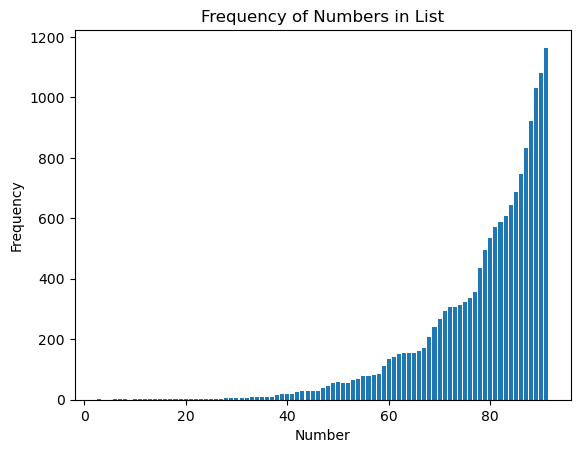

In [23]:
plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [24]:
# so in exp sample, edge number increases as image number increases

In [25]:
# load sim sample again
df = pd.read_csv('Object_relationships.csv')

first_column_list = df.iloc[:, 1].tolist()   # first column

In [26]:
counts = Counter(first_column_list)

print(counts) 

Counter({150: 665, 141: 613, 135: 378, 126: 338, 118: 330, 137: 226, 116: 121, 145: 106, 95: 104, 90: 87, 125: 78, 119: 72, 113: 63, 108: 52, 75: 48, 142: 48, 82: 42, 102: 40, 78: 36, 99: 31, 92: 26, 70: 22, 71: 22, 73: 20, 94: 20, 111: 20, 132: 20, 66: 8, 106: 8, 45: 6, 112: 6, 88: 4, 146: 4, 16: 2, 26: 2, 28: 2, 29: 2, 53: 2, 57: 2, 91: 2, 103: 2, 114: 2})


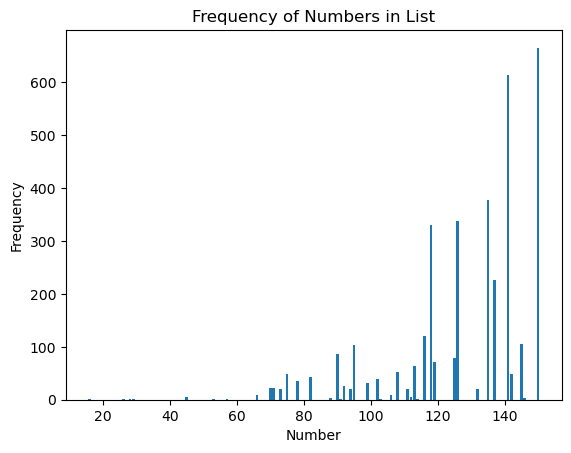

In [27]:
plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [28]:
# so in sim sample, edge number misses many times, and the change is unstable

In [29]:
# this is not good, b/c this means at image t there are 1 egde b/w 2 cells;
# then at image t+1, the edge disappeared but 2 cells are still there.

# also the number of images is 2 times more than exp, and this params are even high values.

In [30]:
# we assumed this is because of the parameter value (too large so we had overlapping issues)

In [31]:
# now let's try low param values which made cell growth very slow.

In [32]:
# load new sim sample
df = pd.read_csv('Object_relationships_low.csv')

first_column_list = df.iloc[:, 1].tolist()   # first column

In [33]:
counts = Counter(first_column_list)

print(counts) 

Counter({598: 845, 589: 812, 551: 696, 593: 688, 556: 662, 631: 660, 586: 652, 612: 606, 533: 605, 544: 574, 510: 542, 622: 532, 605: 517, 590: 500, 559: 498, 613: 472, 537: 467, 552: 460, 501: 442, 509: 438, 522: 430, 463: 420, 466: 380, 571: 379, 520: 378, 476: 368, 579: 356, 534: 346, 529: 344, 426: 338, 500: 326, 511: 326, 430: 324, 527: 324, 564: 318, 572: 318, 469: 300, 477: 300, 416: 298, 549: 298, 484: 296, 515: 294, 402: 292, 492: 292, 378: 284, 517: 280, 433: 278, 464: 276, 455: 274, 539: 274, 396: 270, 445: 262, 424: 260, 526: 258, 603: 256, 614: 250, 381: 242, 352: 241, 489: 238, 507: 238, 480: 236, 536: 234, 490: 232, 391: 230, 460: 230, 487: 228, 405: 226, 395: 224, 596: 224, 496: 216, 414: 214, 408: 212, 457: 212, 628: 212, 418: 210, 385: 208, 419: 206, 600: 196, 461: 194, 483: 194, 444: 192, 561: 190, 380: 184, 573: 184, 450: 180, 494: 180, 422: 178, 630: 178, 387: 176, 410: 176, 441: 176, 427: 174, 435: 174, 376: 172, 431: 172, 439: 170, 555: 170, 615: 168, 585: 166, 4

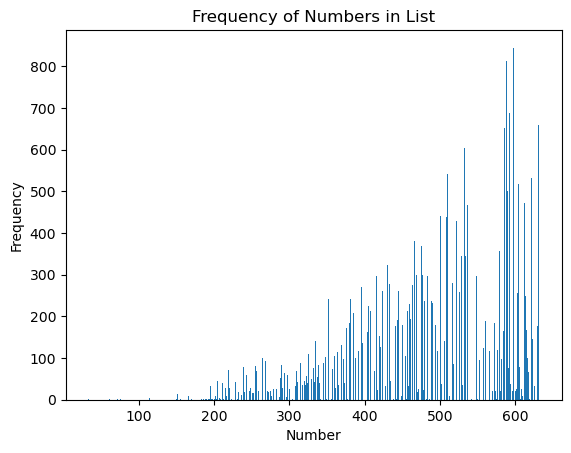

In [34]:
plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [35]:
# issue still there, and even worse b/c of large image number (very slow growth)

In [38]:
# And one thing we can see, last few image these 2 sim samples have similar number of edges (about 700 or 800);
# however, exp sample has about 1200

In [37]:
# now in CM2TR, we just need to fill in those gaps;
# in CM, we want to make growth faster in general so less images are generated;
# in CM, we also need to think about the overlapping discrepancy.

In [110]:
# or another way to fill in those gaps is in graph generation script
# we just need to assume all gaps have the same edges as the previous image.
# this is something called FILLING-IN by BACK-TRACKING

In [39]:
# in terms of param values, when gamma>1,too many image are generated...

In [40]:
# let's try exp samples first

# Define the folder path
path = 'D:/Projects/GNN Research/Data Files/_exp_data/node/'

all_files = glob.glob(os.path.join(path, "*.csv"))

last_cells = []

for filename in all_files:
    try:
        val = pd.read_csv(filename, usecols=[1]).iloc[-1, 0]
        last_cells.append(val)
    except Exception as e:
        print(f"处理文件 {filename} 时出错: {e}")

print(last_cells)


[90, 91, 91, 81, 102, 103, 98, 92, 86, 97, 95, 95, 93, 84, 73, 80, 74, 85, 83, 82, 82, 78, 91, 91]


In [43]:
file_index = np.arange(24)
print(file_index)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


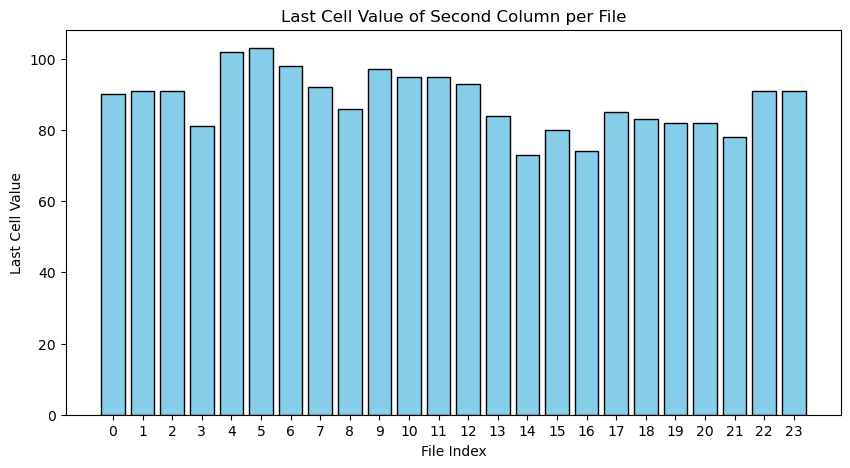

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('Last Cell Value of Second Column per File')
plt.xticks(file_index)  
plt.show()

In [45]:
# so exp samples all have about 90 images

In [46]:
# then let's try sim samples

In [89]:
# Define the folder path
path = 'C:/Users/MECHREV/Desktop/2026-04-15/'
input_folder = [path + f + "/" + os.listdir(path + f)[0] + "/data/" for f in os.listdir(path)]
input_list = [f + os.listdir(f)[0] for f in input_folder]

In [93]:
last_cells = []
gamma_list = []
alpha_list = []

for path in input_list:
    files = glob.glob(os.path.join(path, "*.pickle"))
    last_cells.append(len(files))
    
    match1 = re.search(r"gamma=([\d.]+)", path)
    match2 = re.search(r"reg_param=([\d.]+)", path)

    if match1:
        gamma_value = float(match1.group(1))
        gamma_list.append(gamma_value)
        
    if match2:
        alpha_value = float(match2.group(1))
        alpha_list.append(alpha_value)


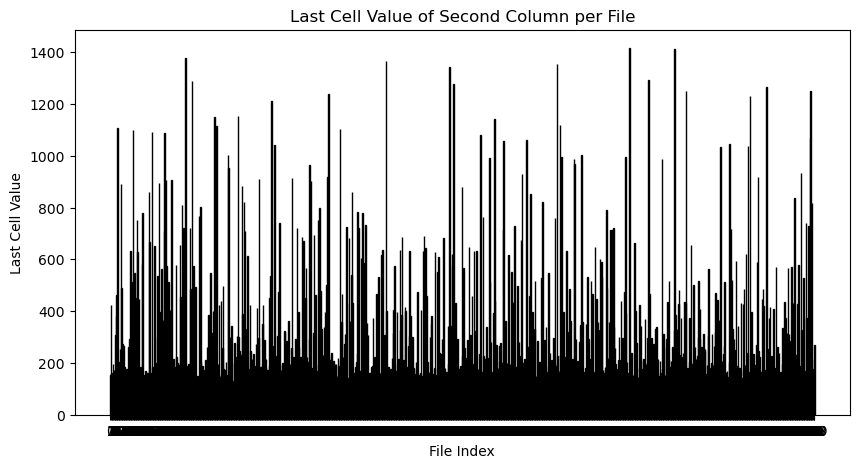

In [87]:
file_index = np.arange(1000)

plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('Last Cell Value of Second Column per File')
plt.xticks(file_index)  
plt.show()

In [109]:
# this is 100% mismatched from exp data

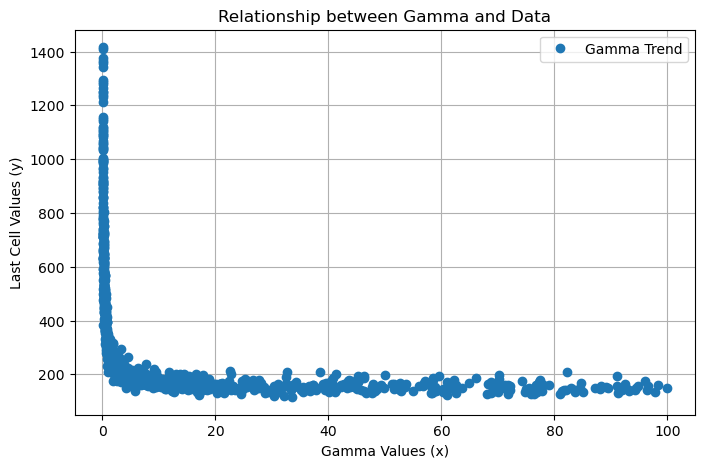

In [96]:
x_values = gamma_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Gamma Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

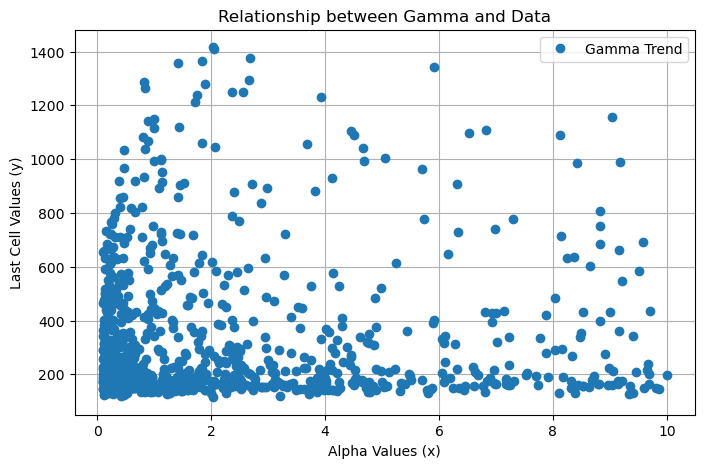

In [97]:
x_values = alpha_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Alpha Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

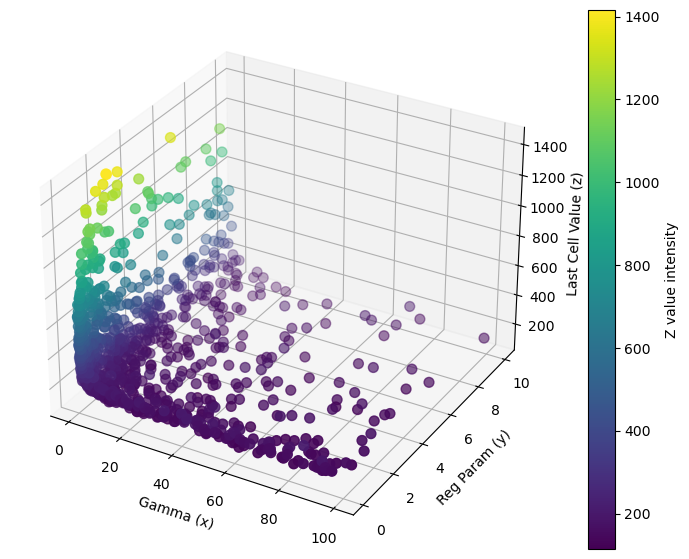

In [98]:
x = gamma_list
y = alpha_list
z = last_cells

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(x, y, z, c=z, cmap='viridis', s=50) 

ax.set_xlabel('Gamma (x)')
ax.set_ylabel('Reg Param (y)')
ax.set_zlabel('Last Cell Value (z)')
fig.colorbar(img, ax=ax, label='Z value intensity')

plt.show()

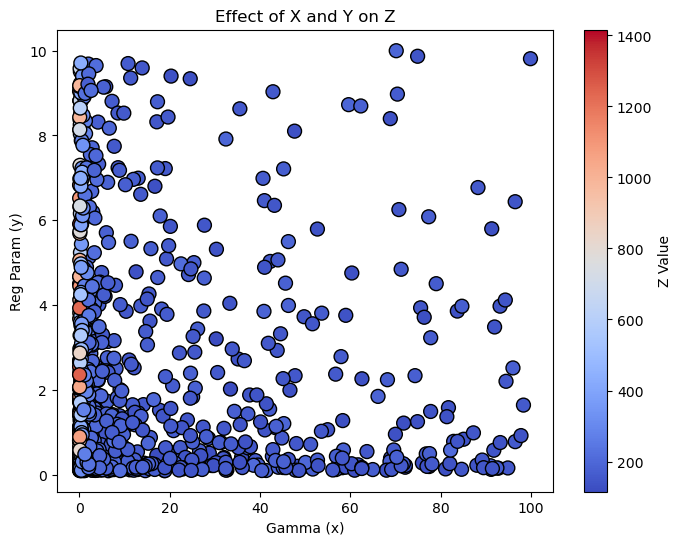

In [99]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(x, y, c=z, s=100, cmap='coolwarm', edgecolors='black')

plt.colorbar(sc, label='Z Value')
plt.xlabel('Gamma (x)')
plt.ylabel('Reg Param (y)')
plt.title('Effect of X and Y on Z')
plt.show()

In [108]:
# clear to see gamma<1 hugely increases number of images (very very slow growth)

In [1]:
# one way to fill in gap images is to directly do it in the OP output csv files, let's try 1 eg.

In [9]:
# load sim sample again
df = pd.read_csv('Object_relationships.csv')

first_column_list = df.iloc[:, 1].tolist()   # first column

counts = Counter(first_column_list)

In [21]:
df

,Relationship,First Image Number,First Object Number,Second Image Number,Second Object Number
0,Neighbors,16,1,16,2
1,Neighbors,16,2,16,1
2,Neighbors,26,1,26,2
3,Neighbors,26,2,26,1
4,Neighbors,28,1,28,2
...,...,...,...,...,...
3677,Neighbors,150,175,150,139
3678,Neighbors,150,175,150,176
3679,Neighbors,150,176,150,12
3680,Neighbors,150,176,150,139


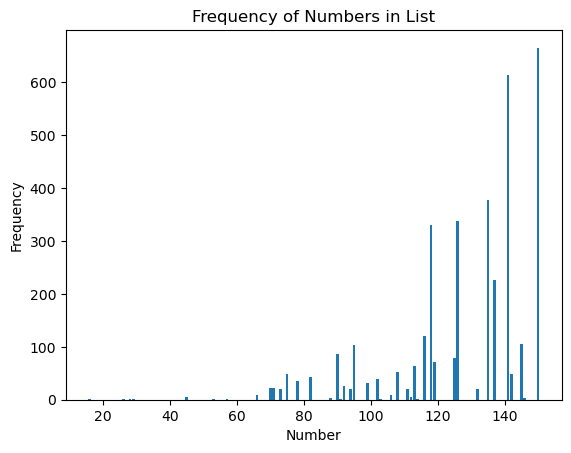

In [10]:
plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [11]:
# we have generated this above, just do it again so we can compare

In [16]:
# get pairs where the count only increases

result = {}
max_so_far = float('-inf')

for k in sorted(counts):  # ensure order
    v = counts[k]
    if v > max_so_far:
        result[k] = v
        max_so_far = v

print(result)

{16: 2, 45: 6, 66: 8, 70: 22, 75: 48, 90: 87, 95: 104, 116: 121, 118: 330, 126: 338, 135: 378, 141: 613, 150: 665}


In [19]:
indices = set(result.keys())  # faster lookup

filtered_df = df[df.iloc[:, 1].isin(indices)]

In [20]:
filtered_df

,Relationship,First Image Number,First Object Number,Second Image Number,Second Object Number
0,Neighbors,16,1,16,2
1,Neighbors,16,2,16,1
8,Neighbors,45,2,45,3
9,Neighbors,45,2,45,5
10,Neighbors,45,3,45,2
...,...,...,...,...,...
3677,Neighbors,150,175,150,139
3678,Neighbors,150,175,150,176
3679,Neighbors,150,176,150,12
3680,Neighbors,150,176,150,139


In [24]:
selected_indices = sorted(indices)

col2 = df.columns[1]   # second column
col4 = df.columns[3]   # fourth column

pieces = []

for i in range(len(selected_indices)):
    start = selected_indices[i]

    base_rows = df[df[col2] == start].copy()
    pieces.append(base_rows)   # keep original rows

    if i < len(selected_indices) - 1:
        next_start = selected_indices[i + 1]

        for new_idx in range(start + 1, next_start):
            copied = base_rows.copy()
            copied[col2] = new_idx
            copied[col4] = new_idx
            pieces.append(copied)

df_filled = pd.concat(pieces, ignore_index=True)
df_filled = df_filled.sort_values(by=col2).reset_index(drop=True)

In [25]:
df_filled

,Relationship,First Image Number,First Object Number,Second Image Number,Second Object Number
0,Neighbors,16,1,16,2
1,Neighbors,16,2,16,1
2,Neighbors,17,1,17,2
3,Neighbors,17,2,17,1
4,Neighbors,18,1,18,2
...,...,...,...,...,...
18034,Neighbors,150,65,150,96
18035,Neighbors,150,66,150,85
18036,Neighbors,150,67,150,34
18037,Neighbors,150,67,150,111


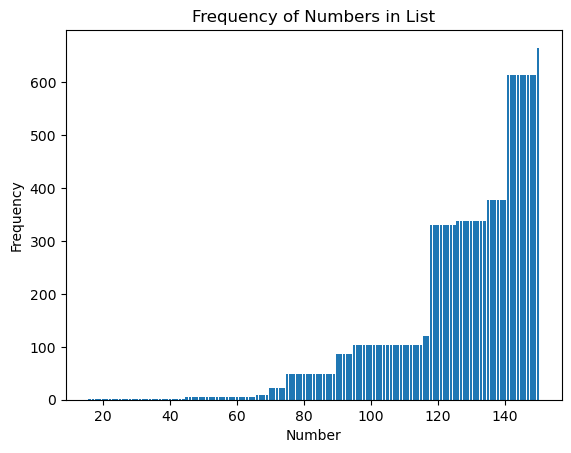

In [26]:
first_column_list = df_filled.iloc[:, 1].tolist()   # first column

counts = Counter(first_column_list)

plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [27]:
# this looks much better
# the number of edges is close to exp as well now

In [1]:
# this approach has 2 assumptions:
# 1. good ones are not bad (b/c nodes are right there)
# 2. bads ones are at least higher than good ones (b/c nodes are right there)

After Ati checked this, the issue is because I used an incompleted outputprocessing script but didn't realize it on time...

Now let's try to analyze the connectivity again.

Note that this sample is gamma=129.2119_reg_param=62.369_iter=50 in 2026/04/25

In [2]:
# load sim sample again
df = pd.read_csv('Object_relationships_new.csv')

first_column_list = df.iloc[:, 1].tolist()   # first column

counts = Counter(first_column_list)

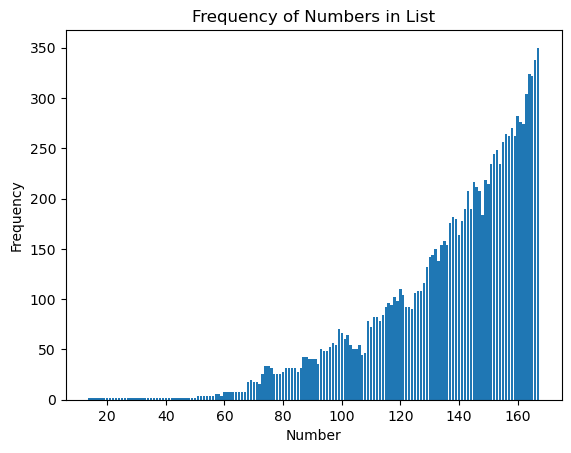

In [3]:
plt.bar(counts.keys(), counts.values())

plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers in List')
plt.show()

In [5]:
first_column_list[-1]

167

In [6]:
first_column_list = set(first_column_list)
len(first_column_list)

154

In [8]:
for i in range(1,168):
    if not i in first_column_list:
        print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13


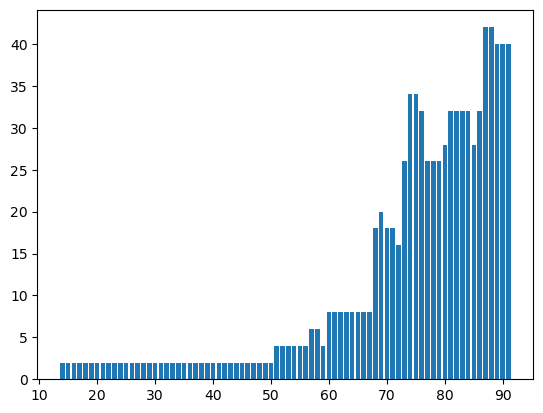

In [12]:
items = list(counts.items())[:78]
keys, values = zip(*items)

plt.bar(keys, values)
plt.show()

In [13]:
# very good, the connectivity issue is solved now!!!!!!!!!!!

### Check 2026/04/25 growth

In [16]:
# Define the folder path
path = 'C:/Users/MECHREV/Desktop/20260425/'
input_folder = [path + f + "/" + os.listdir(path + f)[0] + "/data/" for f in os.listdir(path)]
input_list = [f + os.listdir(f)[0] for f in input_folder]

last_cells = []
gamma_list = []
alpha_list = []

for path in input_list:
    files = glob.glob(os.path.join(path, "*.pickle"))
    last_cells.append(len(files))
    
    match1 = re.search(r"gamma=([\d.]+)", path)
    match2 = re.search(r"reg_param=([\d.]+)", path)

    if match1:
        gamma_value = float(match1.group(1))
        gamma_list.append(gamma_value)
        
    if match2:
        alpha_value = float(match2.group(1))
        alpha_list.append(alpha_value)


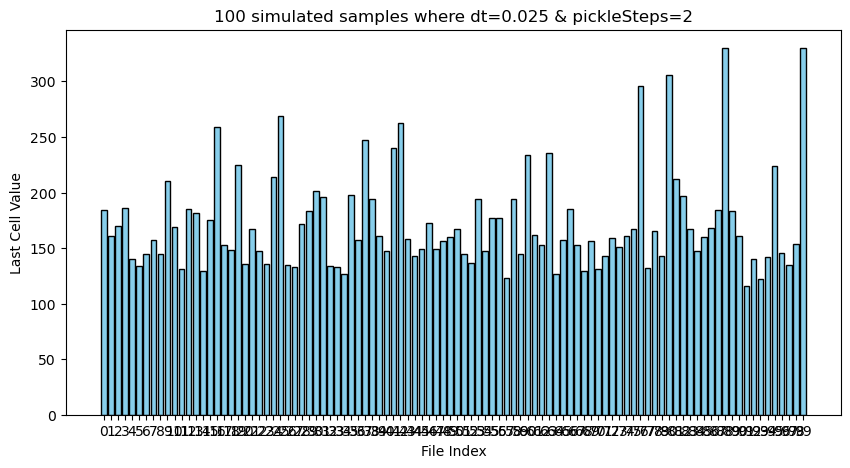

In [17]:
file_index = np.arange(100)

plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('100 simulated samples where dt=0.025 & pickleSteps=2')
plt.xticks(file_index)  
plt.show()

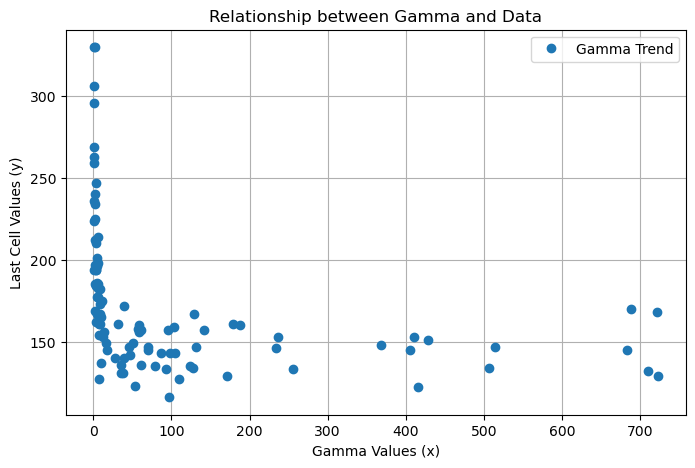

In [18]:
x_values = gamma_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Gamma Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

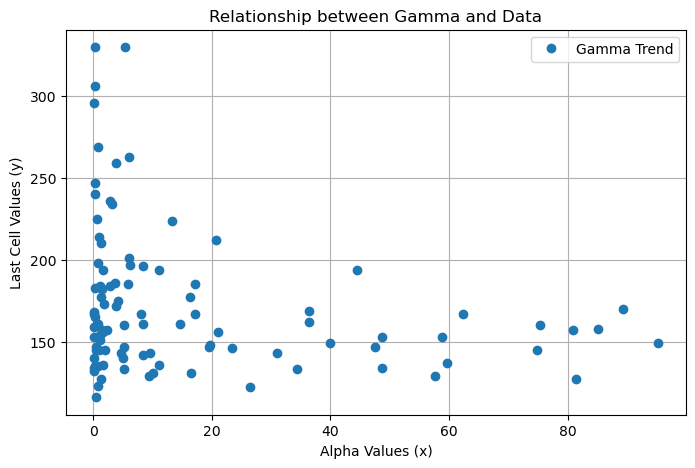

In [19]:
x_values = alpha_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Alpha Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

### Check 2026/04/28 growth

In [20]:
# Define the folder path
path = 'C:/Users/MECHREV/Desktop/20260428/'
input_folder = [path + f + "/" + os.listdir(path + f)[0] + "/data/" for f in os.listdir(path)]
input_list = [f + os.listdir(f)[0] for f in input_folder]

last_cells = []
gamma_list = []
alpha_list = []

for path in input_list:
    files = glob.glob(os.path.join(path, "*.pickle"))
    last_cells.append(len(files))
    
    match1 = re.search(r"gamma=([\d.]+)", path)
    match2 = re.search(r"reg_param=([\d.]+)", path)

    if match1:
        gamma_value = float(match1.group(1))
        gamma_list.append(gamma_value)
        
    if match2:
        alpha_value = float(match2.group(1))
        alpha_list.append(alpha_value)

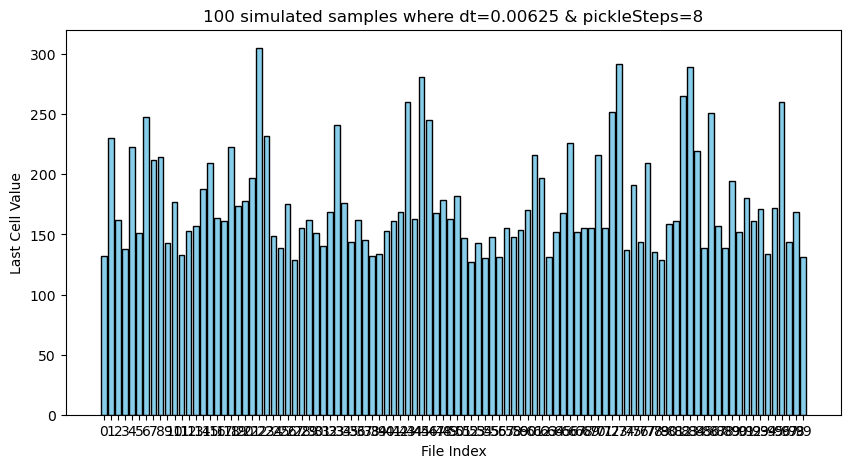

In [21]:
file_index = np.arange(100)

plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('100 simulated samples where dt=0.00625 & pickleSteps=8')
plt.xticks(file_index)  
plt.show()

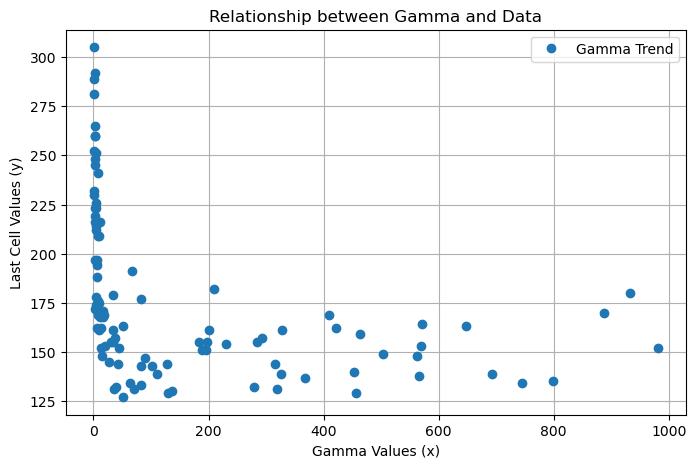

In [22]:
x_values = gamma_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Gamma Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

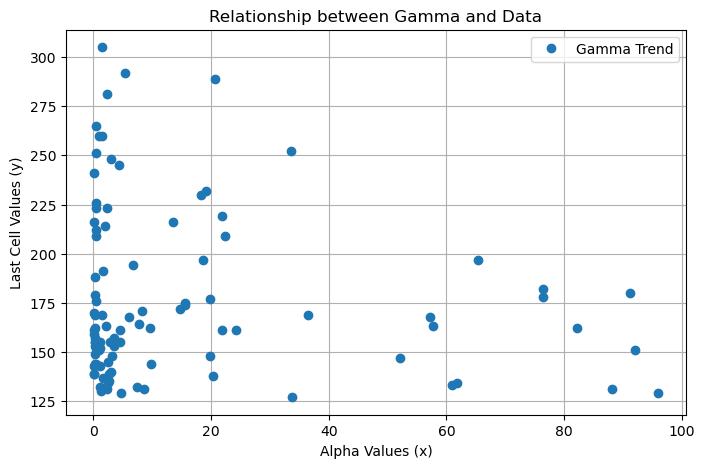

In [23]:
x_values = alpha_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Alpha Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

### Check 2026/04/29 growth

In [24]:
# Define the folder path
path = 'C:/Users/MECHREV/Desktop/20260429/'
input_folder = [path + f + "/" + os.listdir(path + f)[0] + "/data/" for f in os.listdir(path)]
input_list = [f + os.listdir(f)[0] for f in input_folder]

last_cells = []
gamma_list = []
alpha_list = []

for path in input_list:
    files = glob.glob(os.path.join(path, "*.pickle"))
    last_cells.append(len(files))
    
    match1 = re.search(r"gamma=([\d.]+)", path)
    match2 = re.search(r"reg_param=([\d.]+)", path)

    if match1:
        gamma_value = float(match1.group(1))
        gamma_list.append(gamma_value)
        
    if match2:
        alpha_value = float(match2.group(1))
        alpha_list.append(alpha_value)

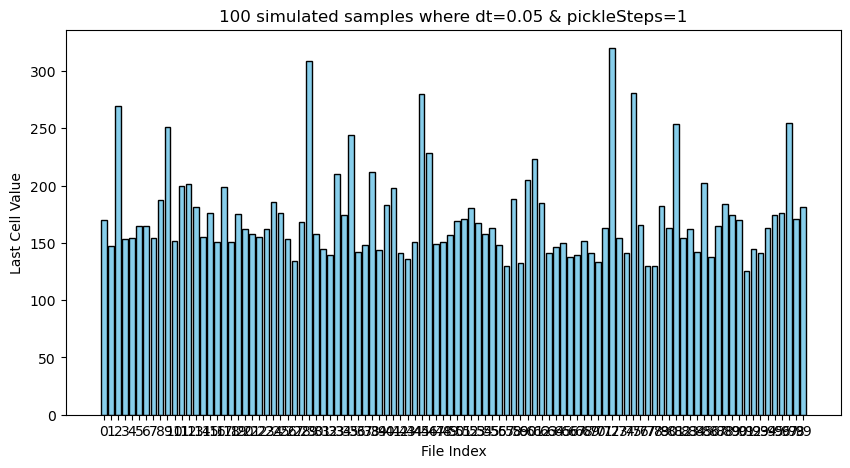

In [25]:
file_index = np.arange(100)

plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('100 simulated samples where dt=0.05 & pickleSteps=1')
plt.xticks(file_index)  
plt.show()

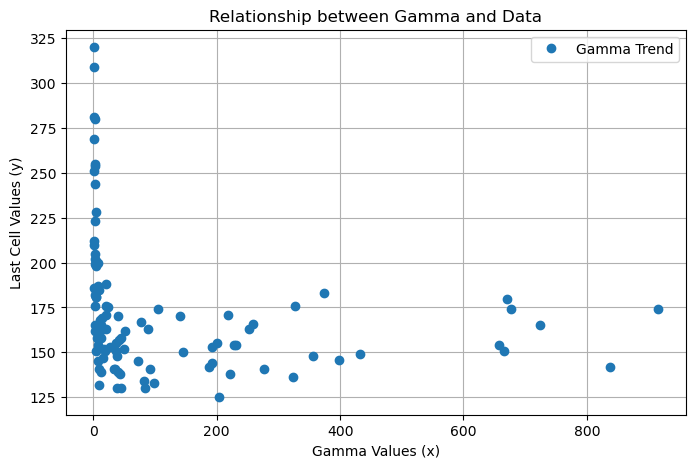

In [26]:
x_values = gamma_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Gamma Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

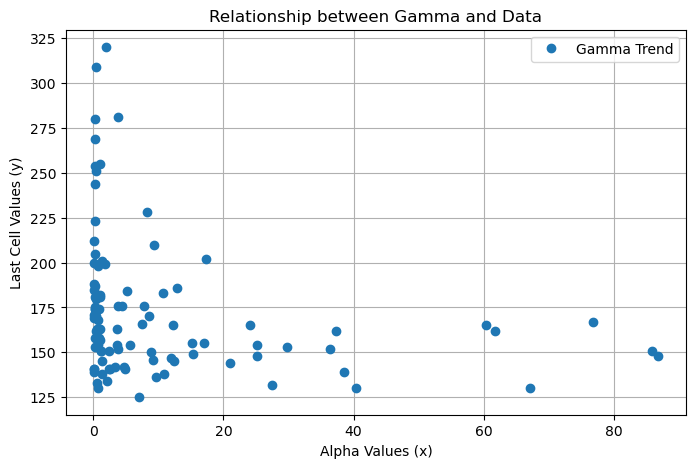

In [27]:
x_values = alpha_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Alpha Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

### Check 2026/04/30 growth

In [2]:
# Define the folder path
path = 'C:/Users/MECHREV/Desktop/20260430/'
input_folder = [path + f + "/" + os.listdir(path + f)[0] + "/data/" for f in os.listdir(path)]
input_list = [f + os.listdir(f)[0] for f in input_folder]

last_cells = []
gamma_list = []
alpha_list = []

for path in input_list:
    files = glob.glob(os.path.join(path, "*.pickle"))
    last_cells.append(len(files))
    
    match1 = re.search(r"gamma=([\d.]+)", path)
    match2 = re.search(r"reg_param=([\d.]+)", path)

    if match1:
        gamma_value = float(match1.group(1))
        gamma_list.append(gamma_value)
        
    if match2:
        alpha_value = float(match2.group(1))
        alpha_list.append(alpha_value)

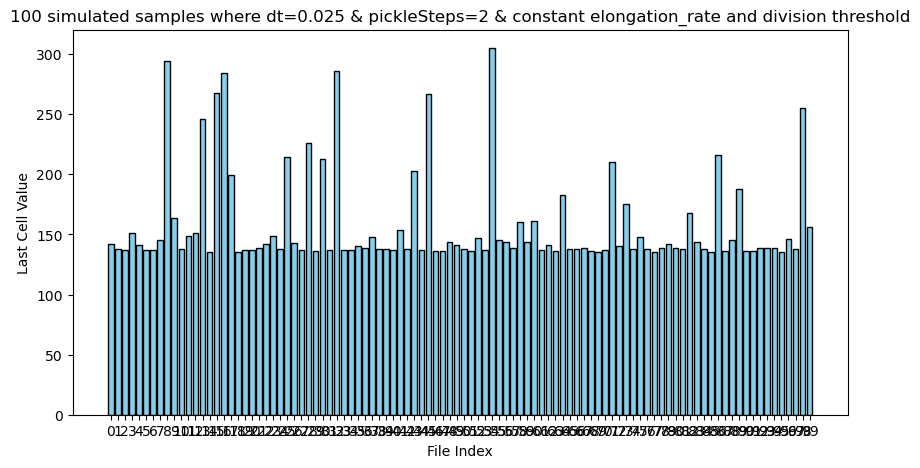

In [6]:
file_index = np.arange(100)

plt.figure(figsize=(10, 5))
plt.bar(file_index, last_cells, color='skyblue', edgecolor='black')

plt.xlabel('File Index')
plt.ylabel('Last Cell Value')
plt.title('100 simulated samples where dt=0.025 & pickleSteps=2 & constant elongation_rate and division threshold')
plt.xticks(file_index)  
plt.show()

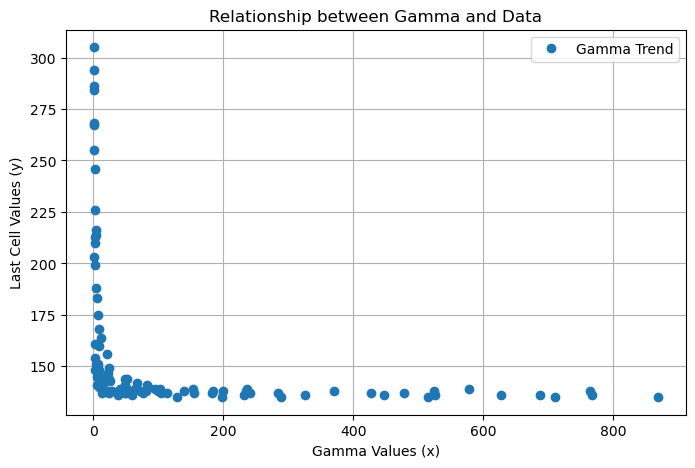

In [4]:
x_values = gamma_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Gamma Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()

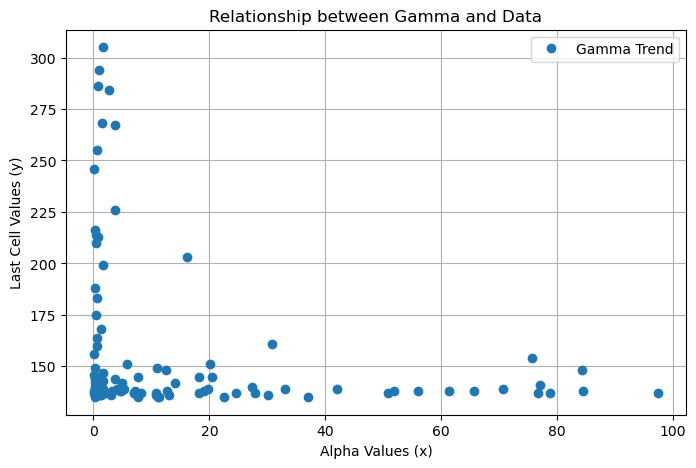

In [5]:
x_values = alpha_list
y_values = last_cells

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, 'o', label='Gamma Trend')

plt.xlabel('Alpha Values (x)')
plt.ylabel('Last Cell Values (y)')
plt.title('Relationship between Gamma and Data')
plt.grid(True) 
plt.legend()
plt.show()